# Experimento — Balanceamento **na origem** (oversampling + augmentation de imagem)

**Hipótese (resposta à crítica do SMOTE):** o professor apontou que o SMOTE atua
num espaço latente de 256 dimensões, onde a "maldição da dimensionalidade" pode
gerar amostras sintéticas ruidosas. Uma alternativa é **balancear na origem**: em
vez de sintetizar pontos no espaço de *embeddings*, oversample as classes
minoritárias **no espaço de imagem** durante o treino da CNN, deixando o
*augmentation* (rotação, flip, brilho…) gerar variações reais a cada época.

**Desenho (idêntico ao nb 01, mudando só o balanceamento):**
- Arquitetura **multimodal** (imagem + clínico), **mesmo split agrupado por
  `lesion_id`** (mesma `SEED`, mesma filtragem) → conjunto de **teste idêntico** ao
  nb 01/02 → comparável.
- Treino com **resampling balanceado** (≈ N/classe): minorias oversample com
  reposição (+ augmentation dá variedade), majoritária subamostrada. Custo de época
  ≈ baseline.
- Validação/teste **intactos** (distribuição real).

**Comparações que isto habilita:**
1. CNN end-to-end: balancear na imagem reduz o colapso melhor que Focal Loss sozinha?
2. Embeddings → XGBoost **sem** SMOTE vs **com** SMOTE: balancear na origem dispensa
   o SMOTE no espaço latente?

**Saídas no Drive (`ICV_imgbalanced_grouped/`):** modelo + embeddings (fused 256-d,
gap 1536-d) das imagens **originais únicas** + rótulos + `lesion_id`.

In [1]:
!pip -q install albumentations opencv-python-headless kagglehub xgboost imbalanced-learn

In [2]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import cv2
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from keras import backend as K
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

IMG_SIZE  = (320, 320)
BATCH_SIZE = 32
AUTOTUNE  = tf.data.AUTOTUNE
SEED      = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
transform = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE[0], IMG_SIZE[1]), scale=(0.70, 1.00), ratio=(0.9, 1.1), p=0.6),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=25,
                       border_mode=cv2.BORDER_REFLECT_101, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.7),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.CoarseDropout(max_holes=4, max_height=IMG_SIZE[0]//10, max_width=IMG_SIZE[1]//10, p=0.4),
], p=1.0)

def augment_image_np(image_np):
    return transform(image=image_np)['image'].astype(np.float32)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_750/2673848387.py:10: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=IMG_SIZE[0]//10, max_width=IMG_SIZE[1]//10, p=0.4),


In [4]:
def find_image_path(image_id, img_dirs, exts=('.jpg','.JPG','.jpeg','.png')):
    for d in img_dirs:
        for ext in exts:
            p = d / f"{image_id}{ext}"
            if p.exists():
                return str(p)
    return None

def categorical_focal_loss(gamma=2.0, alpha=0.75):
    def loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.-K.epsilon())
        ce = -y_true * tf.math.log(y_pred)
        mod = tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(alpha * mod * ce, axis=-1)
    return loss_fixed

def build_image_branch(input_shape):
    inp = layers.Input(shape=input_shape, name="img_input")
    base = EfficientNetB3(weights='imagenet', include_top=False, input_tensor=inp)
    base.trainable = False
    x = layers.GlobalAveragePooling2D(name="image_gap")(base.output)
    x = layers.Dense(128, activation="relu", name="image_dense")(x)
    x = layers.Dropout(0.50)(x)
    return inp, x

def build_clinical_branch(n_features):
    inp = layers.Input(shape=(n_features,), name="clin_input")
    x = layers.Dense(32, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(16, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(8, activation="relu", name="clin_embed")(x)
    return inp, x

def make_dataset(paths, clin, labels_enc, shuffle=False, augment=False):
    paths = [os.fspath(p) for p in paths]
    clin  = np.asarray(clin, dtype=np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, clin, labels_enc))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    def _load(path, c, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE) / 255.0
        return (img, c), tf.one_hot(label, NUM_CLASSES)
    def _aug(inputs, label):
        img, c = inputs
        aug = tf.numpy_function(augment_image_np, [tf.cast(img*255.0, tf.uint8)], tf.float32)
        aug.set_shape(IMG_SIZE + (3,))
        return (aug/255.0, c), label
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(_aug, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [5]:
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
DATA_DIR = Path(path)
meta_csv = next(DATA_DIR.rglob("HAM10000_metadata.csv"))
meta = pd.read_csv(meta_csv)
img_dirs = sorted({p.parent for p in DATA_DIR.rglob("*.jpg")})
print("Dataset em:", DATA_DIR, "| linhas:", len(meta))
assert "lesion_id" in meta.columns

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset em: /kaggle/input/skin-cancer-mnist-ham10000 | linhas: 10015


In [6]:
# Filtragem + features clinicas IDENTICAS ao nb 01 (garante split identico).
meta['image_path'] = meta['image_id'].apply(lambda x: find_image_path(x, img_dirs))
meta = meta[meta['image_path'].notna()].reset_index(drop=True)
meta = meta[meta['sex'] != 'unknown'].copy().reset_index(drop=True)

meta['age'] = meta['age'].replace('unknown', np.nan).astype(float)
meta['age'] = meta['age'].fillna(meta['age'].median())
meta['sex'] = meta['sex'].astype(str).str.lower().map({'male':0,'female':1}).fillna(2).astype(int)
meta['localization'] = meta['localization'].astype('category').cat.codes
clin = meta[['age','sex','localization']].copy().astype(float)
if clin['age'].std() > 0:
    clin['age'] = (clin['age'] - clin['age'].mean()) / clin['age'].std()
CLIN = clin.values.astype(np.float32)
print("N apos preproc:", len(meta))

N apos preproc: 9958


In [7]:
groups = meta['lesion_id'].values
y_dx   = meta['dx'].values
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
trainval_idx, test_idx = next(gss1.split(meta, y_dx, groups))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=SEED)
tr_rel, val_rel = next(gss2.split(meta.iloc[trainval_idx], y_dx[trainval_idx], groups[trainval_idx]))
train_idx = trainval_idx[tr_rel]
val_idx   = trainval_idx[val_rel]
s_tr, s_va, s_te = set(groups[train_idx]), set(groups[val_idx]), set(groups[test_idx])
assert not (s_tr & s_te) and not (s_tr & s_va) and not (s_va & s_te), "LEAKAGE!"
print("OK — split agrupado sem leakage (identico ao nb 01).")
print(f"Treino {len(train_idx)} | Val {len(val_idx)} | Teste {len(test_idx)}")

OK — split agrupado sem leakage (identico ao nb 01).
Treino 7006 | Val 979 | Teste 1973


In [8]:
le = LabelEncoder().fit(meta['dx'].values)
NUM_CLASSES = len(le.classes_)
CLASS_NAMES = list(le.classes_)

def arrays_from_positions(pos):
    return (meta.iloc[pos]['image_path'].values,
            CLIN[pos],
            le.transform(meta.iloc[pos]['dx'].values),
            meta.iloc[pos]['lesion_id'].values)

# splits ORIGINAIS unicos (para extracao de embeddings e avaliacao)
Ximg_tr, Xclin_tr, y_tr, les_tr = arrays_from_positions(train_idx)
Ximg_va, Xclin_va, y_va, les_va = arrays_from_positions(val_idx)
Ximg_te, Xclin_te, y_te, les_te = arrays_from_positions(test_idx)
print("Classes:", CLASS_NAMES)

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


## Balanceamento na origem: resampling do conjunto de treino

Oversample minorias com reposição e subamostra a majoritária para um alvo comum
`N/classe`. Como o *augmentation* é *on-the-fly*, cada cópia de uma imagem
minoritária recebe transformações diferentes a cada época — balanceamento real no
espaço de imagem, sem sintetizar no espaço latente. Val/teste ficam intactos.

In [9]:
rng = np.random.default_rng(SEED)
dx_train = meta['dx'].values[train_idx]
classes  = np.unique(dx_train)
TARGET_PER_CLASS = int(len(train_idx) / len(classes))   # mantem custo de epoca ~ baseline
print("Alvo por classe:", TARGET_PER_CLASS)

bal_pos = []
for c in classes:
    pos_c = train_idx[dx_train == c]
    bal_pos.append(rng.choice(pos_c, size=TARGET_PER_CLASS, replace=True))
bal_pos = np.concatenate(bal_pos)
rng.shuffle(bal_pos)

print("Distribuicao treino balanceado:")
print(pd.Series(meta['dx'].values[bal_pos]).value_counts())

Ximg_bal  = meta.iloc[bal_pos]['image_path'].values
Xclin_bal = CLIN[bal_pos]
y_bal     = le.transform(meta.iloc[bal_pos]['dx'].values)

train_ds = make_dataset(Ximg_bal, Xclin_bal, y_bal, shuffle=True,  augment=True)   # BALANCEADO + aug
val_ds   = make_dataset(Ximg_va,  Xclin_va,  y_va,  shuffle=False, augment=False)
test_ds  = make_dataset(Ximg_te,  Xclin_te,  y_te,  shuffle=False, augment=False)

Alvo por classe: 1000
Distribuicao treino balanceado:
bkl      1000
bcc      1000
vasc     1000
mel      1000
akiec    1000
nv       1000
df       1000
Name: count, dtype: int64


In [10]:
image_in, image_feat = build_image_branch(IMG_SIZE + (3,))
clin_in,  clin_feat  = build_clinical_branch(Xclin_tr.shape[1])
combined = layers.concatenate([image_feat, clin_feat])
z = layers.Dense(256, activation="relu", name="fused_dense_1")(combined)
z = layers.BatchNormalization(name="fused_bn_1")(z)
z = layers.Dropout(0.5, name="fused_dropout_1")(z)
z = layers.Dense(128, activation="relu", name="fused_dense_2")(z)
z = layers.Dropout(0.3, name="fused_dropout_2")(z)
out = layers.Dense(NUM_CLASSES, activation="softmax", name="output_layer")(z)
model = tf.keras.Model(inputs=[image_in, clin_in], outputs=out)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# FASE 1: Focal Loss, backbone congelado, LR 1e-4 (treino sobre dados BALANCEADOS)
for layer in model.layers:
    if 'block' in layer.name:
        layer.trainable = False
    else:
        layer.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=categorical_focal_loss(2.0, 0.75), metrics=["accuracy"])
cb1 = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('bal_fase1.keras', monitor='val_loss', save_best_only=True, verbose=1),
]
hist1 = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=cb1)

Epoch 1/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.1626 - loss: 1.8079
Epoch 1: val_loss improved from None to 1.08817, saving model to bal_fase1.keras

Epoch 1: finished saving model to bal_fase1.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 241s 755ms/step - accuracy: 0.1761 - loss: 1.7194 - val_accuracy: 0.0409 - val_loss: 1.0882 - learning_rate: 1.0000e-04
Epoch 2/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.2212 - loss: 1.4679
Epoch 2: val_loss did not improve from 1.08817
219/219 ━━━━━━━━━━━━━━━━━━━━ 70s 317ms/step - accuracy: 0.2306 - loss: 1.4400 - val_accuracy: 0.0378 - val_loss: 1.2238 - learning_rate: 1.0000e-04
Epoch 3/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.2549 - loss: 1.3384
Epoch 3: val_loss improved from 1.08817 to 1.07868, saving model to bal_fase1.keras

Epoch 3: finished saving model to bal_fase1.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 72s 329ms/step - accuracy: 0.2637 - loss: 1.3295 - val_accuracy: 0.1021 - val_loss: 1.0787 - lea

In [12]:
# FASE 2: fine-tuning leve bloco 7, LR 1e-5
model.load_weights('bal_fase1.keras')
trainable = False
for layer in model.layers:
    if 'block7' in layer.name:
        trainable = True
    layer.trainable = trainable or ('block' not in layer.name)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss=categorical_focal_loss(2.0, 0.75), metrics=["accuracy"])
cb2 = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('bal_fase2.keras', monitor='val_loss', save_best_only=True, verbose=1),
]
hist2 = model.fit(train_ds, validation_data=val_ds, epochs=35, initial_epoch=25, callbacks=cb2)

Epoch 26/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.4161 - loss: 0.8155
Epoch 26: val_loss improved from None to 0.52728, saving model to bal_fase2.keras

Epoch 26: finished saving model to bal_fase2.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 236s 727ms/step - accuracy: 0.4273 - loss: 0.7891 - val_accuracy: 0.5403 - val_loss: 0.5273 - learning_rate: 1.0000e-05
Epoch 27/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.4343 - loss: 0.7660
Epoch 27: val_loss improved from 0.52728 to 0.49092, saving model to bal_fase2.keras

Epoch 27: finished saving model to bal_fase2.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 85s 387ms/step - accuracy: 0.4451 - loss: 0.7492 - val_accuracy: 0.5720 - val_loss: 0.4909 - learning_rate: 1.0000e-05
Epoch 28/35
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.4539 - loss: 0.7095
Epoch 28: val_loss improved from 0.49092 to 0.46801, saving model to bal_fase2.keras

Epoch 28: finished saving model to bal_fase2.keras
219/219 ━━━━━━━━━━━━━━━━━━━━

Relatorio CNN BALANCEADA-NA-ORIGEM (TESTE held-out por lesao):
              precision    recall  f1-score   support

       akiec     0.2431    0.4430    0.3139        79
         bcc     0.2890    0.5495    0.3788        91
         bkl     0.3208    0.0810    0.1293       210
          df     0.0615    0.8000    0.1143        20
         mel     0.2877    0.3962    0.3333       212
          nv     0.9172    0.6853    0.7844      1325
        vasc     0.3279    0.5556    0.4124        36

    accuracy                         0.5727      1973
   macro avg     0.3496    0.5015    0.3523      1973
weighted avg     0.7107    0.5727    0.6151      1973



<Figure size 800x800 with 0 Axes>

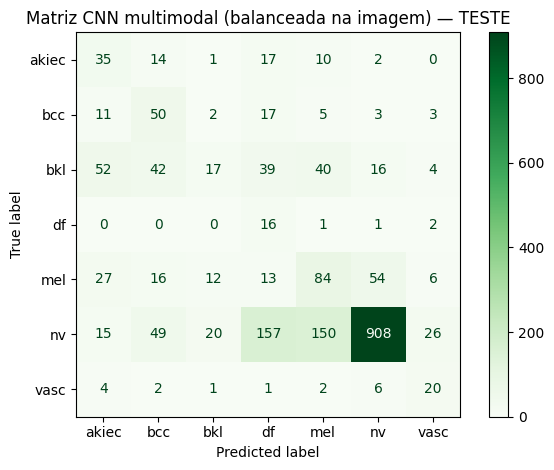

In [13]:
try:    model.load_weights('bal_fase2.keras')
except: model.load_weights('bal_fase1.keras')

y_true, y_pred = [], []
for (Xb, Cb), yb in test_ds:
    p = model.predict([Xb, Cb], verbose=0)
    y_true.extend(np.argmax(yb.numpy(), axis=1))
    y_pred.extend(np.argmax(p, axis=1))

print("Relatorio CNN BALANCEADA-NA-ORIGEM (TESTE held-out por lesao):")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap=plt.cm.Greens, values_format='d')
plt.title('Matriz CNN multimodal (balanceada na imagem) — TESTE')
plt.tight_layout(); plt.savefig('matrix_imgbalanced.png', dpi=150); plt.show()

In [14]:
# Embeddings das imagens ORIGINAIS UNICAS (mesmo protocolo do nb 01).
extr_fused = tf.keras.Model(model.inputs, model.get_layer("fused_dense_1").output)
extr_gap   = tf.keras.Model(model.inputs, model.get_layer("image_gap").output)

def extract(paths, clin, labels_enc):
    ds = make_dataset(paths, clin, labels_enc, shuffle=False, augment=False)
    return extr_fused.predict(ds, verbose=1), extr_gap.predict(ds, verbose=1)

f_tr, g_tr = extract(Ximg_tr, Xclin_tr, y_tr)
f_va, g_va = extract(Ximg_va, Xclin_va, y_va)
f_te, g_te = extract(Ximg_te, Xclin_te, y_te)
print("fused:", f_tr.shape, f_te.shape, "| gap:", g_tr.shape, g_te.shape)

219/219 ━━━━━━━━━━━━━━━━━━━━ 89s 352ms/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 70s 265ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 475ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 495ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 329ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 345ms/step
fused: (7006, 256) (1973, 256) | gap: (7006, 1536) (1973, 1536)


In [16]:
from google.colab import drive
drive.mount('/content/drive')
OUT = Path('/content/drive/MyDrive/ICV_imgbalanced_grouped')
OUT.mkdir(parents=True, exist_ok=True)
model.save(OUT / 'modelo_imgbalanced_grouped.keras')

def save_split(tag, f, g, clin, y, les):
    np.save(OUT / f'X_{tag}_fused.npy', f)
    np.save(OUT / f'X_{tag}_gap.npy',   g)
    np.save(OUT / f'X_{tag}_clin.npy',  np.asarray(clin, dtype=np.float32))
    np.save(OUT / f'y_{tag}.npy',       np.asarray(y))
    np.save(OUT / f'lesion_{tag}.npy',  np.asarray(les))
save_split('train', f_tr, g_tr, Xclin_tr, y_tr, les_tr)
save_split('val',   f_va, g_va, Xclin_va, y_va, les_va)
save_split('test',  f_te, g_te, Xclin_te, y_te, les_te)

manifest = {
    "modelo": "multimodal — balanceamento na origem (oversampling+aug de imagem)",
    "target_per_class_treino": int(TARGET_PER_CLASS),
    "classes": CLASS_NAMES,
    "split": {"train": int(len(train_idx)), "val": int(len(val_idx)), "test": int(len(test_idx))},
    "leakage_check": {"train_test": len(s_tr & s_te), "train_val": len(s_tr & s_va), "val_test": len(s_va & s_te)},
    "dist_teste": meta.iloc[test_idx]['dx'].value_counts().to_dict(),
    "split_method": "GroupShuffleSplit por lesion_id (70/10/20), SEED=42 — IDENTICO ao nb01/02",
}
(OUT / 'split_manifest_imgbalanced.json').write_text(json.dumps(manifest, indent=2, ensure_ascii=False))
print("Salvo em:", OUT); print(json.dumps(manifest, indent=2, ensure_ascii=False))

Mounted at /content/drive
Salvo em: /content/drive/MyDrive/ICV_imgbalanced_grouped
{
  "modelo": "multimodal — balanceamento na origem (oversampling+aug de imagem)",
  "target_per_class_treino": 1000,
  "classes": [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
  ],
  "split": {
    "train": 7006,
    "val": 979,
    "test": 1973
  },
  "leakage_check": {
    "train_test": 0,
    "train_val": 0,
    "val_test": 0
  },
  "dist_teste": {
    "nv": 1325,
    "mel": 212,
    "bkl": 210,
    "bcc": 91,
    "akiec": 79,
    "vasc": 36,
    "df": 20
  },
  "split_method": "GroupShuffleSplit por lesion_id (70/10/20), SEED=42 — IDENTICO ao nb01/02"
}


## Próximos passos

1. Baixe `ICV_imgbalanced_grouped/` (os `.npy` + `split_manifest_imgbalanced.json`).
2. Junte aos embeddings dos nb 01 (multimodal padrão) e nb 02 (image-only). Eu rodo
   o XGBoost sobre os três e monto a comparação de **estratégias de balanceamento**:

   | Estratégia | CNN recall mel | XGBoost recall mel | +SMOTE recall mel |
   |---|---|---|---|
   | nb01: Focal Loss (sem balance imagem) | … | … | … |
   | **nb03: balance na imagem (oversampling+aug)** | … | … | (SMOTE redundante?) |

3. **Leitura do resultado:** se o nb03 (balance na imagem) → XGBoost **sem** SMOTE já
   igualar/superar o nb01 **com** SMOTE, temos evidência de que balancear na origem é
   uma alternativa válida ao SMOTE em 256-d — exatamente a dúvida levantada pela banca.
4. Confirme que `dist_teste` bate com os manifestos dos nb 01/02 (mesmo teste).
